Cloud_Parcel Example Usage

In [1]:
# importing necessary packages
import pyrcel as pm
from pyrcel_runner import Cloud_Parcel

c:\Users\mamu9533\.locaa\envs\pyrcel_model_env\lib\site-packages\pyrcel\constants.py:47: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
# define some aerosol species using pyrcel's built in function
ammonium_sulfate =  pm.AerosolSpecies('Ammonium Sulfate',
                             pm.Lognorm(mu=0.015, sigma=1.6, N=850.),
                             kappa=0.8, bins=200)
sea_salt = pm.AerosolSpecies('sea salt',
                             pm.Lognorm(mu=0.85, sigma=1.2, N=10.),
                             kappa=1.2, bins=40)

In [3]:
# define an instance of Cloud_Parcel. T0, P0, etc represent meteorological characteristics at the ground. H represents boundary layer height
# you can also specify max_cloud_thickness, which will limit the height of the cloud and (somewhat) account for lack of entrainment in pyrcel

cloud_test = Cloud_Parcel(T0=275, P0=77000, S0=-0.02, H=500, V=1, aerosols=[ammonium_sulfate, sea_salt], max_cloud_thickness=100)

In [4]:
# use .run_pyrcel() to run the parcel model
cloud_test.run_pyrcel()
print("Model run completed\n"+"="*100)

# use .add_cloud_microphysics to compute microphysics
cloud_test.add_cloud_microphysics()
print("Microphysics computed")

# ex: print height-resolved effective radii computed from .add_cloud_microphysics()
print(f"Sample output: integrated optical depth is {cloud_test.total_tau}\n"+"="*100)

# use .compute_optical_properties() to run the monte_carlo model. You can specify the number of photons, asymmetry parameter, etc
n_photons = 1000
cloud_test.compute_optical_properties(N=n_photons, with_absorbance=True)
print("Monte Carlo model run completed")

# ex: print optical properties computed from monte carlo model
print(f"Transmittance: {cloud_test.transmittance}")
print(f"Reflectance: {cloud_test.reflectance}")
print(f"Absorbance: {cloud_test.absorbance}")

Could not find cannot import name 'dopri5' from 'assimulo.lib' (c:\Users\mamu9533\.locaa\envs\pyrcel_model_env\lib\site-packages\assimulo\lib\__init__.py)
Could not find cannot import name 'rodas' from 'assimulo.lib' (c:\Users\mamu9533\.locaa\envs\pyrcel_model_env\lib\site-packages\assimulo\lib\__init__.py)
Could not find cannot import name 'odassl' from 'assimulo.lib' (c:\Users\mamu9533\.locaa\envs\pyrcel_model_env\lib\site-packages\assimulo\lib\__init__.py)
Could not find ODEPACK functions.
Could not find RADAR5
Could not find GLIMDA.


Model run completed
Microphysics computed
Sample output: integrated optical depth is 2.0777018598006034
Monte Carlo model run completed
Transmittance: 0.834
Reflectance: 0.131
Absorbance: 0.035


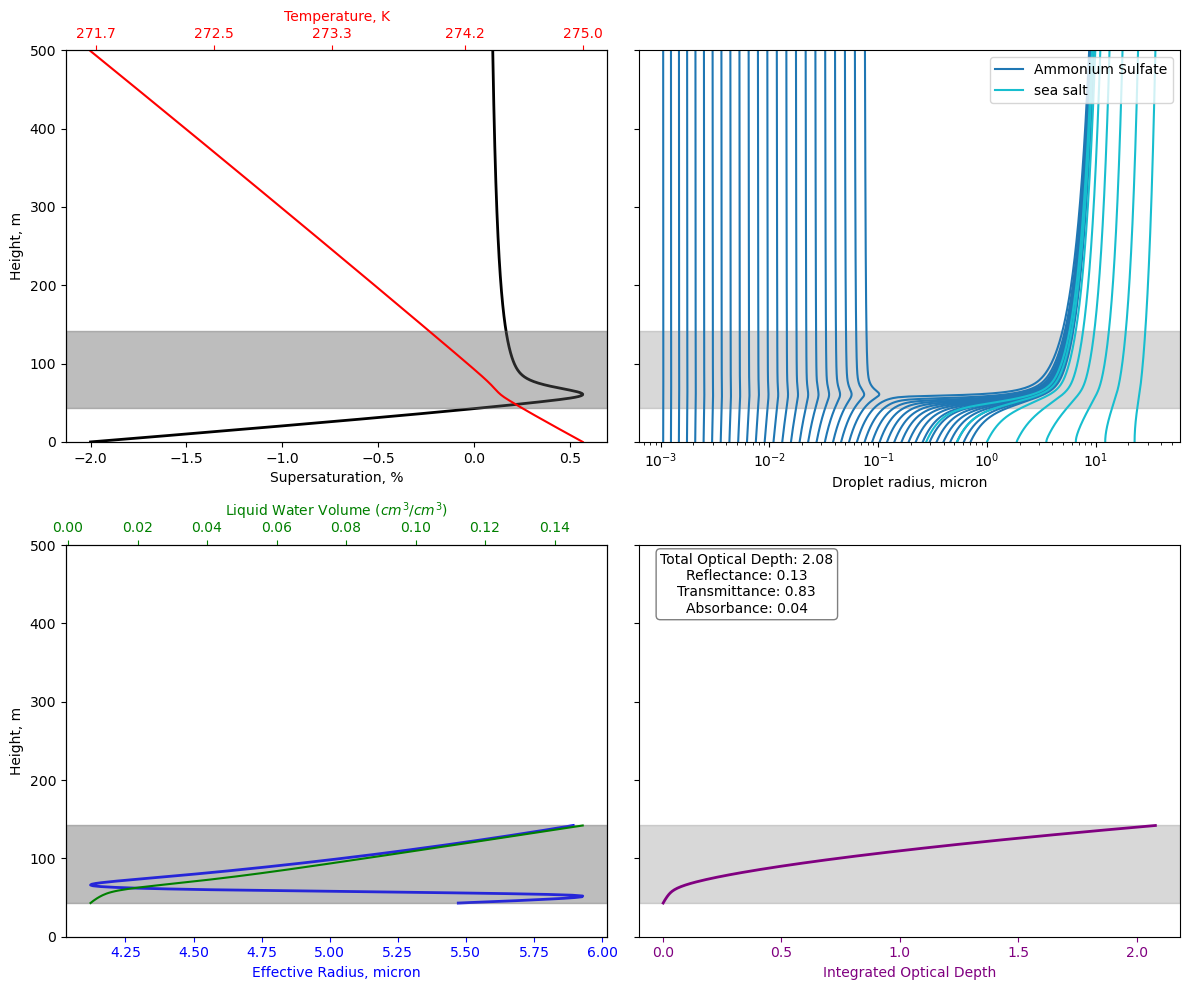

In [5]:
# use .summarize_and_visualize() to create a visualization
cloud_test.summarize_and_visualize()

NPF Case Study: How does an evolving aerosol population affect cloud reflectivity?

In [ ]:
#importing packages
import xarray as xr
import matplotlib.pyplot as plt
from joblib import Parallel, delayed #speeds up model runs

In [7]:
# Reads in example file. This data was taken from the Southern Great Plains DOE ARM site, near Lamont, OK
ds = xr.open_dataset(r"npf_example.nc")

In [16]:
# This block uses Cloud_Parcel to run individual pyrcel runs, then returns optical depth / reflectivity

# specify model parameters
updraft_velocity = 1.0  # 1 m/s
cloud_thickness = 150   # meters
photon_no = 1000        # number of photons for monte_carlo

def run_single(a, t, s, p, b, k):
    aer = pm.AerosolSpecies('SGP_aerosol', {'r_drys': ds['radius'].values, 'Nis': a}, kappa=k)
    
    cloud = Cloud_Parcel(T0=t, P0=p, S0=s, H=b, V=updraft_velocity, aerosols=[aer], max_cloud_thickness=cloud_thickness)
    cloud.run_pyrcel()
    cloud.add_cloud_microphysics()
    cloud.compute_optical_properties(N=photon_no, with_absorbance=True)
    
    return cloud.reflectance, cloud.total_tau

results = Parallel(n_jobs=-1)(
    delayed(run_single)(a, t, s, p, b, k)
    for a, t, s, p, b, k in tqdm(zip(
        ds['aerosol'].values,
        ds['temperature'].values,
        ds['supersaturation'].values,
        ds['atmos_pressure'].values,
        ds['boundary_layer_h'].values+250,
        ds['kappa'].values
    ), total=len(ds['aerosol'].values))
)

reflectance, taus = zip(*results)
reflectance = list(reflectance)
taus = list(taus)

100%|██████████| 293/293 [46:55<00:00,  9.61s/it] 


In [12]:
from tqdm import tqdm

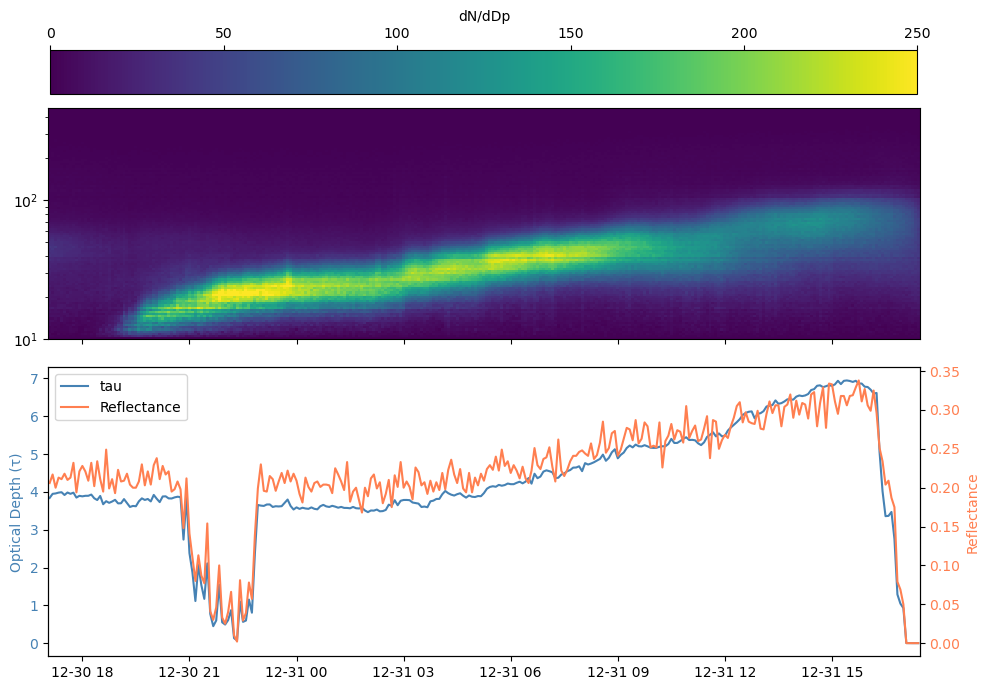

In [17]:
# Plotting the results

import numpy as np

fig, ax = plt.subplots(2, 1, sharex=True, figsize=(10, 7))
X = ds['time'].values
Y = ds['radius'].values * 2 * 10**3
Z = ds['aerosol'].values

Xmesh, Ymesh = np.meshgrid(X, Y)

mesh = ax[0].pcolormesh(Xmesh, Ymesh, Z.T, shading='nearest', vmin=None, vmax=250)
ax[0].set_ylim([10, 460])
ax[0].set_yscale('log')
fig.colorbar(mesh, label='dN/dDp', orientation='horizontal', location='top')

# tau
ax[1].plot(X, taus, color='steelblue', label='tau')
ax[1].set_ylabel('Optical Depth (τ)', color='steelblue')
ax[1].tick_params(axis='y', labelcolor='steelblue')

# reflectance on twin axis
ax1_twin = ax[1].twinx()
ax1_twin.plot(X, reflectance, color='coral', label='Reflectance')
ax1_twin.set_ylabel('Reflectance', color='coral')
ax1_twin.tick_params(axis='y', labelcolor='coral')

# combined legend
lines1, labels1 = ax[1].get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()
ax[1].legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
# TO DO
# upload to github
# add some commits, namely name guards for all the classes
# add README, toml, etc.
# upload to testpy then test